# AZIKU SAMUEL
# 2301201228 / 2023/U/MCS/1228


In [ ]:
import numpy as np  # For numerical operations and array handling
import pandas as pd  # For loading and handling data from CSV
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns
from sklearn.linear_model import LinearRegression  # For comparison model
from sklearn.metrics import mean_squared_error  # For calculating MSE

# Classifiers
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from sklearn.utils import estimator_html_repr
from IPython.display import display, HTML

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import FunctionTransformer
from joblib import load
from joblib import dump

# Statsmodels
from statsmodels.stats.contingency_tables import mcnemar

# OFL-IDS
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Special SMOTE-compatible pipeline

# Confusion matrix
from sklearn.metrics import confusion_matrix

# New section

In [ ]:
import os
os.makedirs('saved_models', exist_ok=True)

In [ ]:
df = pd.read_csv("azikus.csv", encoding='latin1')

1.1 Basic Dataset Overview

In [ ]:
# 1. Basic Dataset Overview
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (80, 19)

First 5 Rows:
       Current_Role Years_at_Institution Manages_Accesses_Sensitive_Data  \
0  Lecturer / Tutor    More than 6 years                             Yes   
1  Lecturer / Tutor            1-3 years                              No   
2  Lecturer / Tutor            1-3 years                              No   
3  Lecturer / Tutor            4-6 years                              No   
4  Lecturer / Tutor            1-3 years                              No   

         Sensitive_Data_Types  \
0  Health and Medical Records   
1  Health and Medical Records   
2  Health and Medical Records   
3           Financial Records   
4  Health and Medical Records   

                                 Data_Storage_Method Regular_Data_Backup  \
0  Paper Based;Local Computers;External drives / ...                 Yes   
1              Cloud Servers;External drives / Disks            Not Sure   
2                        Paper Based;Local Computers                  No   
3

<h1>1.2 Statistical Summary</h1>

In [ ]:
print("\nNumerical Features Summary:")
print(df.describe())

print("\nCategorical Features Summary:")
print(df.select_dtypes(include='object').describe())


Numerical Features Summary:
            Current_Role Years_at_Institution Manages_Accesses_Sensitive_Data  \
count                 80                   80                              80   
unique                 9                    5                               2   
top     Lecturer / Tutor            1-3 years                             Yes   
freq                  21                   25                              51   

              Sensitive_Data_Types  \
count                           80   
unique                           6   
top     Health and Medical Records   
freq                            23   

                                      Data_Storage_Method Regular_Data_Backup  \
count                                                  80                  80   
unique                                                  6                   3   
top     Paper Based;Local Computers;External drives / ...                  No   
freq                                              

<h1>1.3 Target Variable Analysis</h1>

In [ ]:
df = pd.read_csv("azikus.csv", encoding='latin1')
df[['Current_Role','Years_at_Institution','Manages_Accesses_Sensitive_Data','Sensitive_Data_Types','Data_Storage_Method','Regular_Data_Backup','Data_Access_Permissions','Aware_of_Data_Protection_Policies','Data_Protection_Effectiveness_Rating','Experienced_Data_Breach_or_Loss','Data_Breach_Description','Data_Privacy_Risks','Sensitive_Data_Protection_Status','Aware_of_Pseudonymization','Pseudonymization_Understanding','Perceived_Usefulness_of_Pseudonymization','Pseudonymization_Challenges','Recommended_Data_Privacy_Measures','Interested_in_Pilot_Project']].value_counts()

Current_Role            Years_at_Institution  Manages_Accesses_Sensitive_Data  Sensitive_Data_Types        Data_Storage_Method                                  Regular_Data_Backup  Data_Access_Permissions  Aware_of_Data_Protection_Policies  Data_Protection_Effectiveness_Rating  Experienced_Data_Breach_or_Loss  Data_Breach_Description  Data_Privacy_Risks                                                                                                                           Sensitive_Data_Protection_Status    Aware_of_Pseudonymization  Pseudonymization_Understanding  Perceived_Usefulness_of_Pseudonymization  Pseudonymization_Challenges                                                                    Recommended_Data_Privacy_Measures                Interested_in_Pilot_Project
Administrator           1-3 years             No                               Staff Records               Cloud Servers;External drives / Disks                Not Sure             Yes                      Yes                                Very Effective                        Yes                              Leaked Marks             Weak or No Passwords;Lack of data encryption                                                                                                 Password Protection;Access Control  No                         Intermediate                    Not Sure                                  Cost of implementation                                                                         Staff training and stronger access controls #9   Not sure                       1
                                                                                                           Paper Based;Local Computers                          Yes                  Yes                      Yes                                Very Effective                        No                               Not Applicable           Unauthorised Access;Weak or No Passwords                                                                                                     Access Control                      Yes                        Only Heard the term             Useful                                    Cost of implementation                                                                         Staff training and stronger access controls #4   Not sure                       1
                                              Yes                              Health and Medical Records  Cloud Servers;External drives / Disks                No                   Yes                      Yes                                Not sure                              No                               Not Applicable           Unauthorised Access;Weak or No Passwords                                                                                                     Password Protection                 No                         Basic                           Not Sure                                  System compatibility issues                                                                    Staff training and stronger access controls #21  Yes                            1
                                                                               Staff Records               Paper Based;Local Computers                          Yes                  Yes                      No                                 Not sure                              No                               Not Applicable           Weak or No Passwords;Lack of data encryption                                                                                                 Password Protection;Access Control  Yes                        Only Heard the term             Useful                                    Lack of Technical Knowledge                                                                    Multi-factor authentication #48                  Not sure                       1
                                             

/tmp/ipykernel_4473/3618016273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Years_at_Institution',palette='viridis', data=df, order=df['Years_at_Institution'].value_counts().index)


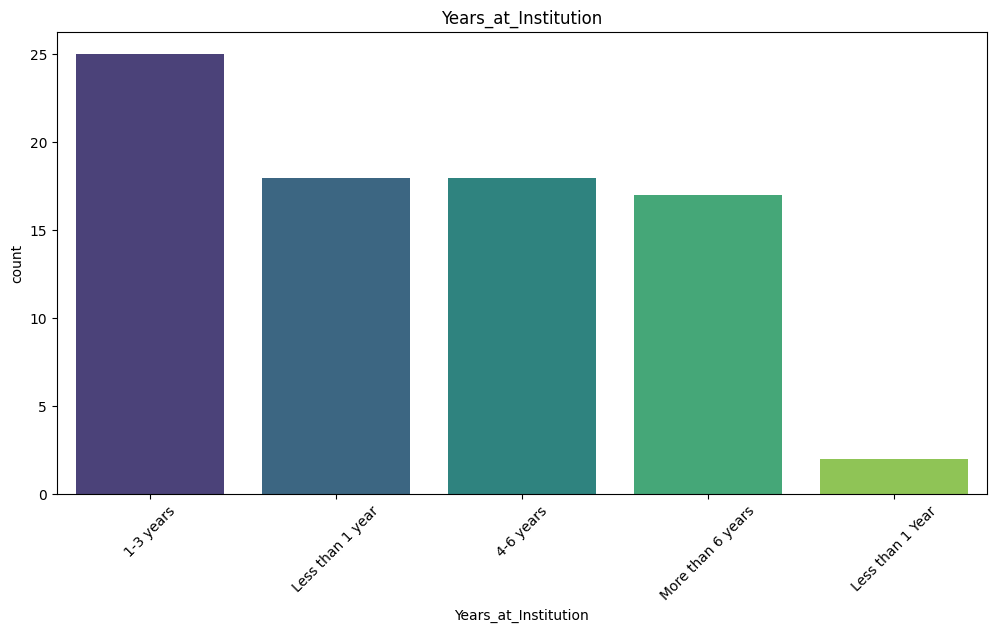

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='Years_at_Institution',palette='viridis', data=df, order=df['Years_at_Institution'].value_counts().index)
plt.title('Years_at_Institution')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_4473/1307552691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Data_Storage_Method',  palette='viridis', data=df, order=df['Data_Storage_Method'].value_counts().index)


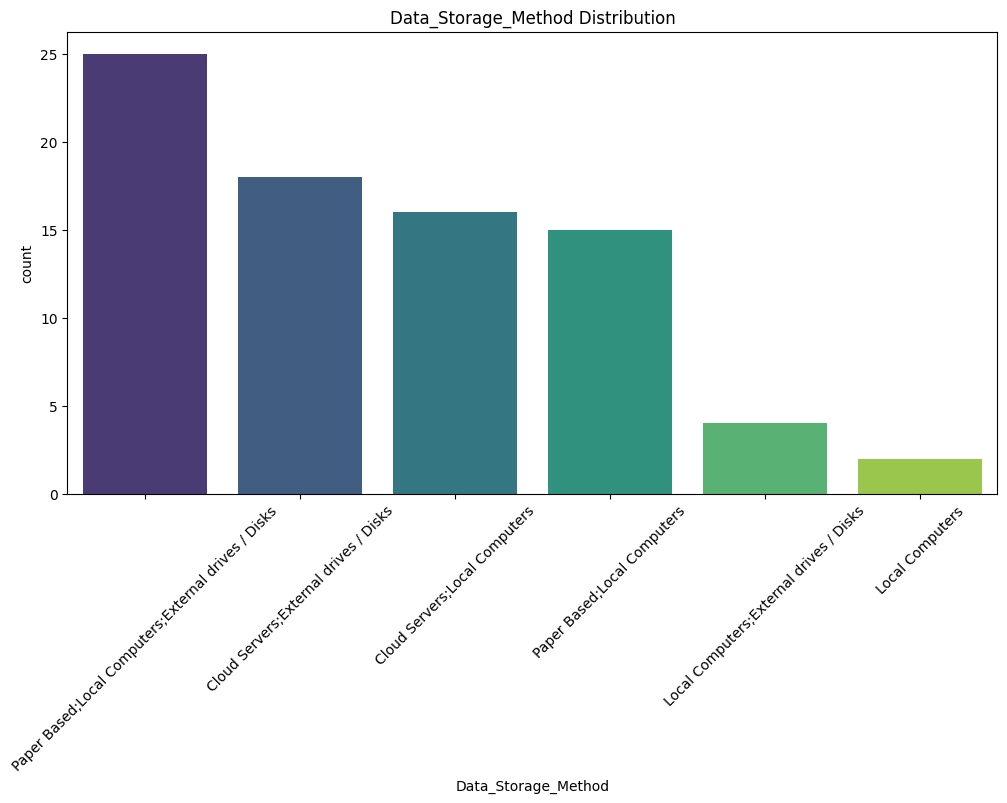

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='Data_Storage_Method',  palette='viridis', data=df, order=df['Data_Storage_Method'].value_counts().index)
plt.title('Data_Storage_Method Distribution')
plt.xticks(rotation=45)
plt.show()

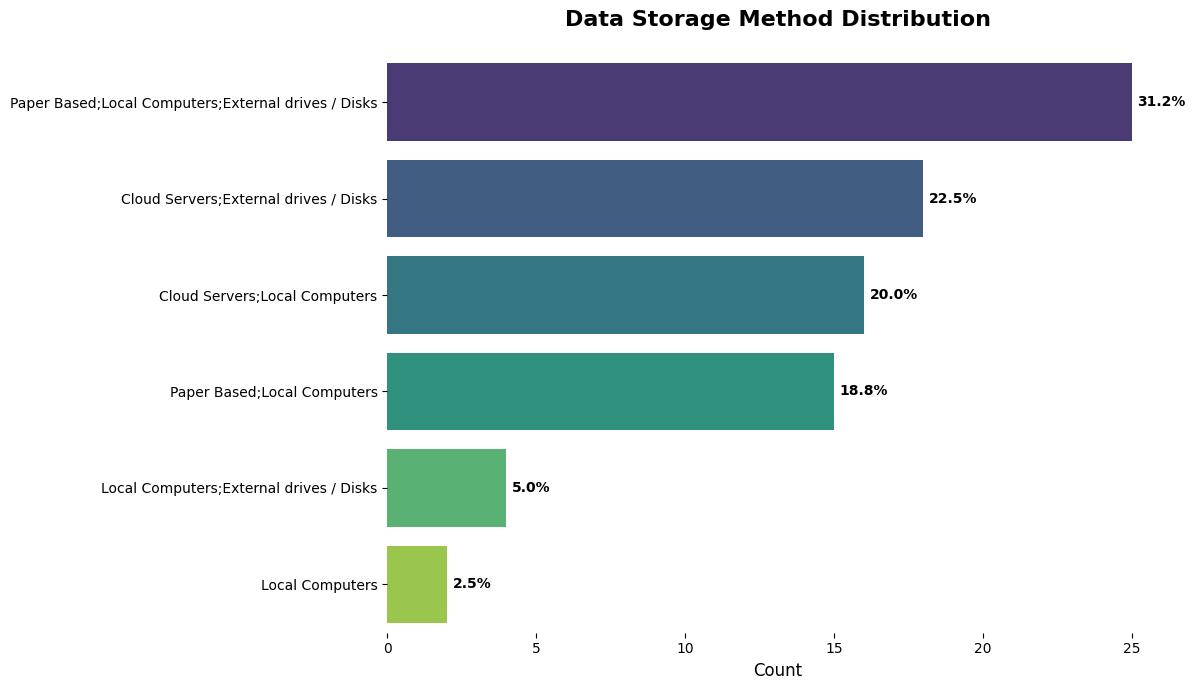

In [ ]:
# 1. Prepare Data
data = df['Data_Storage_Method'].value_counts()

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Create Horizontal Bar Plot
# Using hue=data.index solves the FutureWarning
# Setting legend=False hides the redundant color key
sns.barplot(
    y=data.index,
    x=data.values,
    palette='viridis',
    hue=data.index,
    legend=False,
    ax=ax
)

# 4. Add Percentages
total = data.sum()
for i, v in enumerate(data.values):
    percentage = f'{100 * v / total:.1f}%'
    ax.text(v + 0.2, i, percentage, color='black', va='center', fontweight='bold')

# 5. Styling & Labels
ax.set_title('Data Storage Method Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('', fontsize=12)
sns.despine(left=True, bottom=True)  # Clean up the look by removing borders

plt.tight_layout()
plt.show()

## The chart shows that Kajokeji Health Training Institute primarily relies on a combination of paper-based records, local computers, and external storage devices, which accounts for 31.2% of respondents. Other common storage methods include the use of cloud servers with external drives (22.5%), cloud servers with local computers (20.0%), and paper-based records with local computers (18.8%). Only a small proportion of respondents use local computers with external drives (5.0%) or local computers alone (2.5%). Overall, the findings indicate that the institute predominantly employs hybrid data storage systems, combining both traditional and digital storage methods to manage sensitive information. This highlights the need for strong privacy-preserving measures, such as pseudonymization, to protect data across multiple storage platforms.

In [ ]:
# Frequency count
df['Current_Role'].value_counts()

# Frequency percentage
df['Current_Role'].value_counts(normalize=True) * 100

,proportion
Current_Role,
Lecturer / Tutor,26.25
Administrator,21.25
Records Officer,17.50
ICT Staff,15.00
Department Head,7.50
Management,3.75
Secreteriate / Records,3.75
Others,2.50
Student,2.50


In [ ]:
columns = [
    'Current_Role',
    'Years_at_Institution',
    'Manages_Accesses_Sensitive_Data',
    'Sensitive_Data_Types',
    'Data_Storage_Method',
    'Regular_Data_Backup',
    'Data_Access_Permissions',
    'Aware_of_Data_Protection_Policies',
    'Data_Protection_Effectiveness_Rating',
    'Experienced_Data_Breach_or_Loss',
    'Data_Breach_Description',
    'Data_Privacy_Risks',
    'Sensitive_Data_Protection_Status',
    'Aware_of_Pseudonymization',
    'Pseudonymization_Understanding',
    'Perceived_Usefulness_of_Pseudonymization',
    'Pseudonymization_Challenges',
    'Recommended_Data_Privacy_Measures',
    'Interested_in_Pilot_Project'
]

for col in columns:
    print(f"\nFrequency for {col}")
    print(df[col].value_counts())
    print("\nPercentage:")
    print(df[col].value_counts(normalize=True) * 100)


Frequency for Current_Role
Current_Role
Lecturer / Tutor          21
Administrator             17
Records Officer           14
ICT Staff                 12
Department Head            6
Management                 3
Secreteriate / Records     3
Others                     2
Student                    2
Name: count, dtype: int64

Percentage:
Current_Role
Lecturer / Tutor          26.25
Administrator             21.25
Records Officer           17.50
ICT Staff                 15.00
Department Head            7.50
Management                 3.75
Secreteriate / Records     3.75
Others                     2.50
Student                    2.50
Name: proportion, dtype: float64

Frequency for Years_at_Institution
Years_at_Institution
1-3 years            25
Less than 1 year     18
4-6 years            18
More than 6 years    17
Less than 1 Year      2
Name: count, dtype: int64

Percentage:
Years_at_Institution
1-3 years            31.25
Less than 1 year     22.50
4-6 years            22.50
More th

In [ ]:
df = pd.read_csv("azikus.csv", encoding='latin1')
df[['Current_Role','Years_at_Institution','Manages_Accesses_Sensitive_Data','Sensitive_Data_Types','Data_Storage_Method','Regular_Data_Backup','Data_Access_Permissions','Aware_of_Data_Protection_Policies','Data_Protection_Effectiveness_Rating','Experienced_Data_Breach_or_Loss','Data_Breach_Description','Data_Privacy_Risks','Sensitive_Data_Protection_Status','Aware_of_Pseudonymization','Pseudonymization_Understanding','Perceived_Usefulness_of_Pseudonymization','Pseudonymization_Challenges','Recommended_Data_Privacy_Measures','Interested_in_Pilot_Project']].value_counts()

Current_Role            Years_at_Institution  Manages_Accesses_Sensitive_Data  Sensitive_Data_Types        Data_Storage_Method                                  Regular_Data_Backup  Data_Access_Permissions  Aware_of_Data_Protection_Policies  Data_Protection_Effectiveness_Rating  Experienced_Data_Breach_or_Loss  Data_Breach_Description  Data_Privacy_Risks                                                                                                                           Sensitive_Data_Protection_Status    Aware_of_Pseudonymization  Pseudonymization_Understanding  Perceived_Usefulness_of_Pseudonymization  Pseudonymization_Challenges                                                                    Recommended_Data_Privacy_Measures                Interested_in_Pilot_Project
Administrator           1-3 years             No                               Staff Records               Cloud Servers;External drives / Disks                Not Sure             Yes                      Yes                                Very Effective                        Yes                              Leaked Marks             Weak or No Passwords;Lack of data encryption                                                                                                 Password Protection;Access Control  No                         Intermediate                    Not Sure                                  Cost of implementation                                                                         Staff training and stronger access controls #9   Not sure                       1
                                                                                                           Paper Based;Local Computers                          Yes                  Yes                      Yes                                Very Effective                        No                               Not Applicable           Unauthorised Access;Weak or No Passwords                                                                                                     Access Control                      Yes                        Only Heard the term             Useful                                    Cost of implementation                                                                         Staff training and stronger access controls #4   Not sure                       1
                                              Yes                              Health and Medical Records  Cloud Servers;External drives / Disks                No                   Yes                      Yes                                Not sure                              No                               Not Applicable           Unauthorised Access;Weak or No Passwords                                                                                                     Password Protection                 No                         Basic                           Not Sure                                  System compatibility issues                                                                    Staff training and stronger access controls #21  Yes                            1
                                                                               Staff Records               Paper Based;Local Computers                          Yes                  Yes                      No                                 Not sure                              No                               Not Applicable           Weak or No Passwords;Lack of data encryption                                                                                                 Password Protection;Access Control  Yes                        Only Heard the term             Useful                                    Lack of Technical Knowledge                                                                    Multi-factor authentication #48                  Not sure                       1
                                             

In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Sensitive_Data_Types')

,Frequency,Percentage (%)
Sensitive_Data_Types,,
Health and Medical Records,23,28.75
Staff Records,22,27.50
Students' Personal Data,18,22.50
Financial Records,15,18.75
Staff details,1,1.25
Health and Medical Record,1,1.25


In [ ]:
pd.crosstab(df['Sensitive_Data_Types'], df['Data_Access_Permissions'])

Data_Access_Permissions,No,Not Sure,Yes
Sensitive_Data_Types,,,
Financial Records,1,2,12
Health and Medical Record,0,0,1
Health and Medical Records,5,0,18
Staff Records,0,1,21
Staff details,0,0,1
Students' Personal Data,5,3,10


In [ ]:
pd.crosstab(df['Sensitive_Data_Types'], df['Current_Role'], normalize='index') * 100

Current_Role,Administrator,Department Head,ICT Staff,Lecturer / Tutor,Management,Others,Records Officer,Secreteriate / Records,Student
Sensitive_Data_Types,,,,,,,,,
Financial Records,13.333333,6.666667,13.333333,26.666667,0.000000,0.000000,33.333333,0.000000,6.666667
Health and Medical Record,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Health and Medical Records,26.086957,13.043478,4.347826,30.434783,8.695652,0.000000,8.695652,4.347826,4.347826
Staff Records,31.818182,0.000000,27.272727,9.090909,0.000000,0.000000,27.272727,4.545455,0.000000
Staff details,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000
Students' Personal Data,11.111111,11.111111,11.111111,44.444444,5.555556,11.111111,5.555556,0.000000,0.000000


/tmp/ipykernel_4473/1244819840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Aware_of_Pseudonymization',  palette='viridis',  data=df)


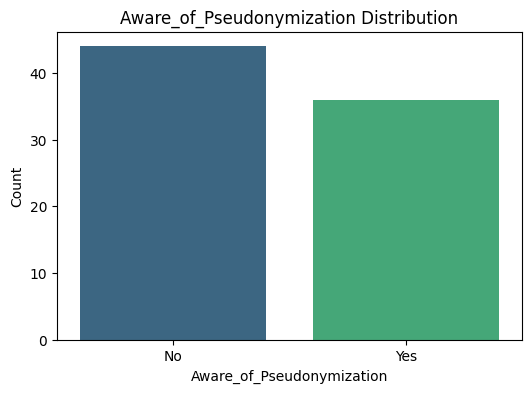

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Aware_of_Pseudonymization',  palette='viridis',  data=df)

plt.title("Aware_of_Pseudonymization Distribution")
plt.xlabel("Aware_of_Pseudonymization")
plt.ylabel("Count")

plt.show()

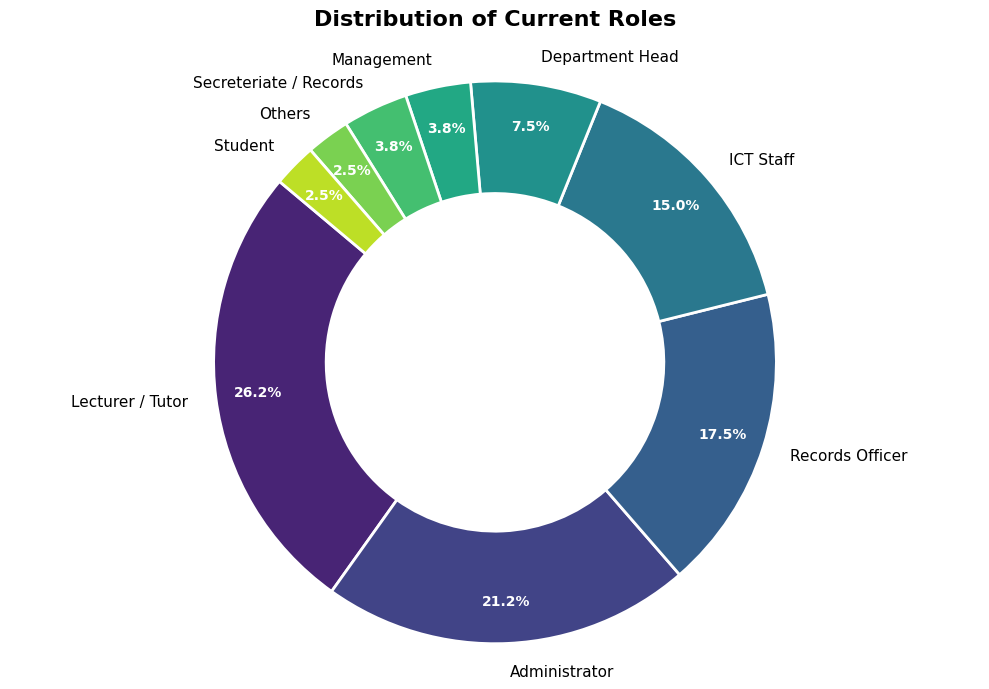

In [ ]:
# 1. Prepare Data
# Sorting values ensures the plot follows a logical order
data = df['Current_Role'].value_counts()
labels = data.index
sizes = data.values

# 2. Styling
# Use a professional color palette
colors = sns.color_palette('viridis', len(labels))

fig, ax = plt.subplots(figsize=(10, 7))

# 3. Create the Donut
# Increase wedgeprops width for a modern look
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=colors,
    wedgeprops={'width': 0.4, 'edgecolor': 'w', 'linewidth': 2}
)

# 4. Enhance Readability
plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=11)

# Add a clean center label
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig.gca().add_artist(centre_circle)

# 5. Final Touches
plt.title("Distribution of Current Roles", fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')  # Ensure the pie is drawn as a circle
plt.tight_layout()
plt.show()

*The donut chart illustrates the distribution of respondents by current role at Kajokeji Health Training Institute, showing a sample dominated by Lecturers/Tutors (26.2%), followed by Administrators (21.2%) and Records Officers (17.5%), with ICT Staff (15.0%) also significantly represented. Smaller proportions include Department Heads (7.5%), Management and Secretariat/Records Support (each 3.8%), and minor contributions from Students and Others (2.5% each). This distribution highlights that the study mainly reflects perspectives from key academic, administrative, and data-handling personnel who are directly involved in managing and securing sensitive institutional information, making the dataset suitable for analyzing data privacy and pseudonymization practices.*




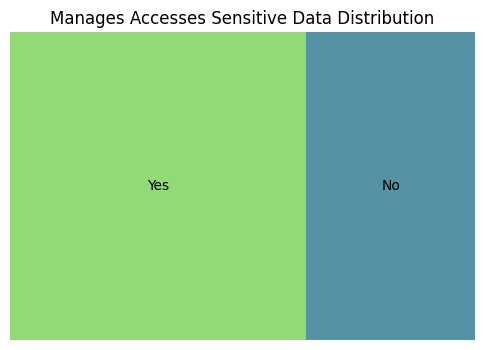

In [ ]:
!pip install squarify
import squarify
import matplotlib.pyplot as plt

freq = df['Manages_Accesses_Sensitive_Data'].value_counts()

plt.figure(figsize=(6,4))
squarify.plot(sizes=freq.values, label=freq.index, alpha=0.8)

plt.title("Manages Accesses Sensitive Data Distribution")
plt.axis('off')

plt.show()

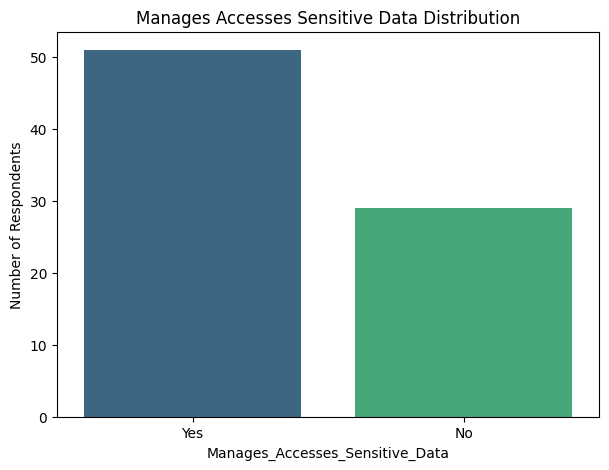

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Manages_Accesses_Sensitive_Data',
    data=df,
    order=df['Manages_Accesses_Sensitive_Data'].value_counts().index,
    palette='viridis',
    hue='Manages_Accesses_Sensitive_Data',
    legend=False
)

plt.title('Manages Accesses Sensitive Data Distribution')
plt.xlabel('Manages_Accesses_Sensitive_Data')
plt.ylabel('Number of Respondents')
plt.show()


The results show that a majority of respondents, approximately 51 individuals, indicated “Yes”, meaning they are directly involved in handling or accessing sensitive institutional data. In contrast, about 29 respondents selected “No”, indicating that they do not directly manage or interact with sensitive data.

This distribution highlights that most participants in the study are actively engaged in data-related roles, which increases the relevance of their responses to issues of data privacy, protection, and pseudonymization. The higher proportion of “Yes” responses suggests that the institution relies heavily on staff who routinely handle sensitive records such as student information, academic records, and administrative data.





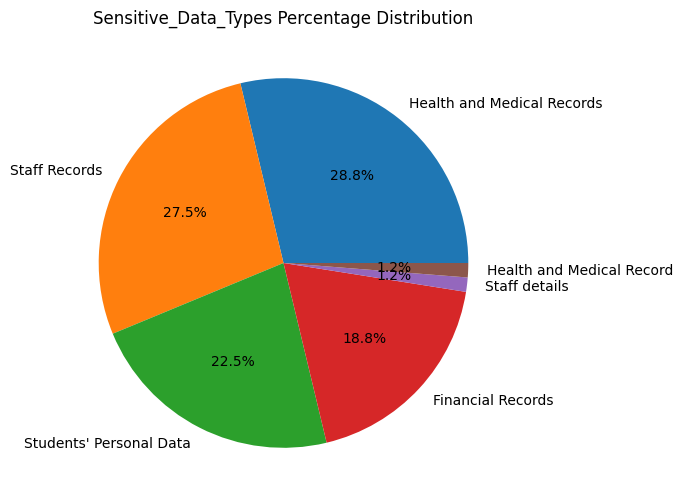

In [ ]:
df['Sensitive_Data_Types'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title('Sensitive_Data_Types Percentage Distribution')
plt.ylabel('')

plt.show()

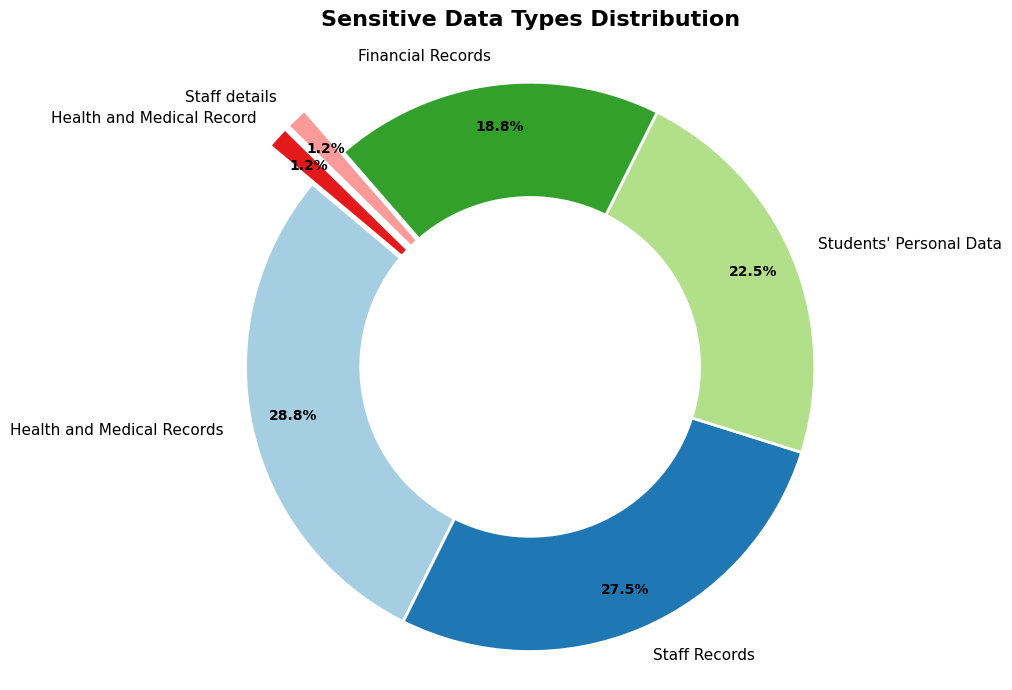

In [ ]:
# 1. Prepare Data
data = df['Sensitive_Data_Types'].value_counts()

# 2. Styling
# Use a visually distinct color map
colors = plt.cm.Paired.colors

# Explode the small segments to make them stand out
explode = [0, 0, 0, 0, 0.2, 0.2]

# 3. Create Pie Chart
fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts, autotexts = ax.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# 4. Enhance Readability
# Formatting the percentage text
plt.setp(autotexts, size=10, weight="bold")
plt.setp(texts, size=11)

# Add a clean white circle in the middle to turn it into a modern "donut-pie"
# This makes it much easier to read the labels
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
ax.add_artist(centre_circle)

plt.title('Sensitive Data Types Distribution', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

### The chart indicates that Health and Medical Records (28.8%) and Staff Records (27.5%) are the most common types of sensitive data stored at Kajokeji Health Training Institute, followed by Students’ Personal Data (22.5%) and Financial Records (18.8%). Together, these categories account for the vast majority of sensitive information managed by the institution. The findings highlight that the institute handles substantial amounts of confidential personal, medical, and financial data, emphasizing the importance of implementing strong privacy protection measures such as pseudonymization to safeguard information from unauthorized access and disclosure.

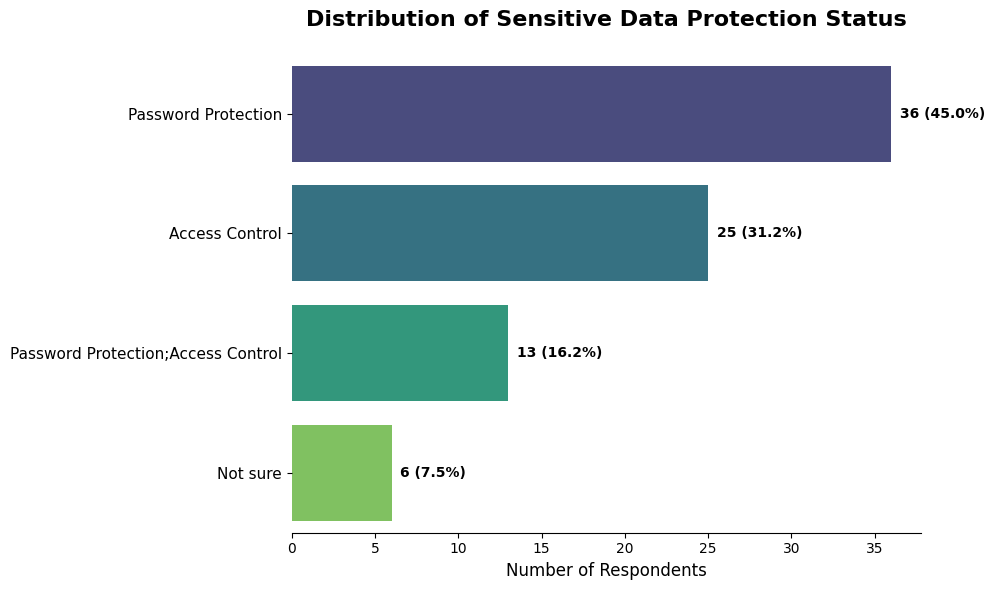

In [ ]:
# 1. Prepare and calculate proportions
data = df['Sensitive_Data_Protection_Status'].value_counts()
total = data.sum()

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create Horizontal Bar Plot
# Using 'viridis' palette with a smooth gradient
sns.barplot(
    y=data.index,
    x=data.values,
    palette='viridis',
    hue=data.index,
    legend=False,
    ax=ax
)

# 4. Add data labels (Count + Percentage)
for i, v in enumerate(data.values):
    pct = (v / total) * 100
    ax.text(v + 0.5, i, f'{v} ({pct:.1f}%)', color='black', va='center', fontweight='bold')

# 5. Professional Styling
ax.set_title('Distribution of Sensitive Data Protection Status', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Respondents', fontsize=12)
ax.set_ylabel('', fontsize=12) # Removed Y label as it's clear from title

# Clean up axes (Dissertation charts should be minimalist)
sns.despine(left=True, bottom=False)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

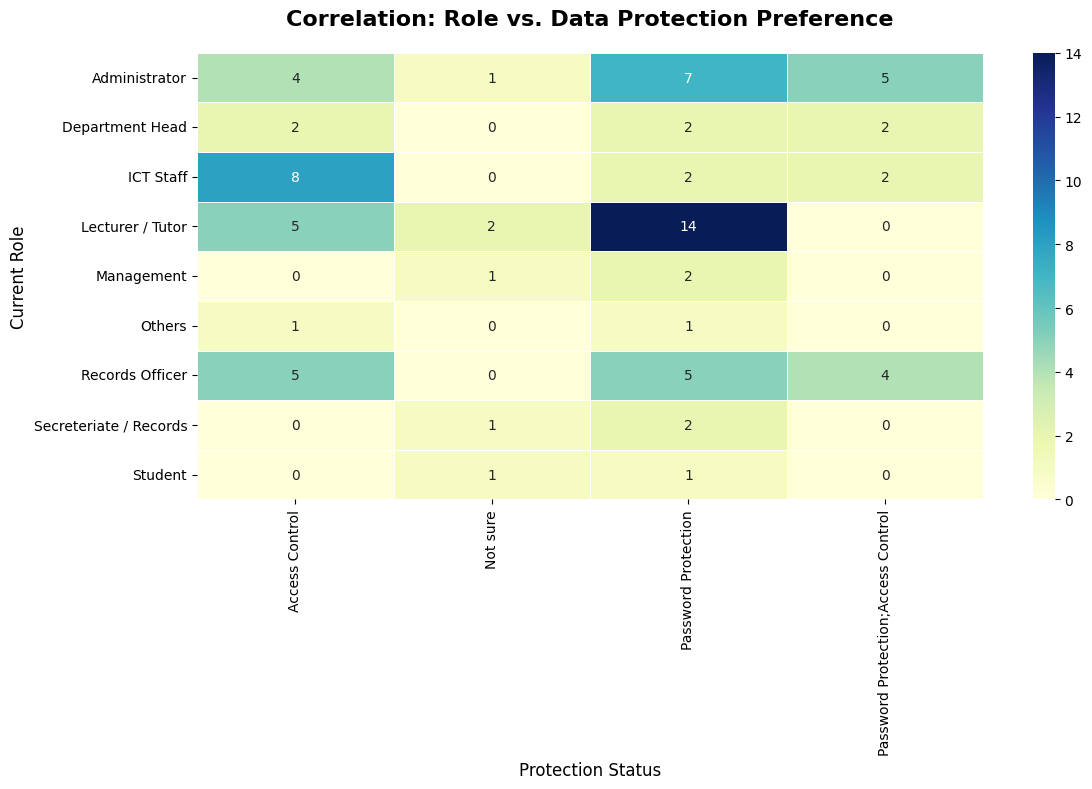

In [ ]:
# Assuming you want to compare "Current_Role" vs "Sensitive_Data_Protection_Status"
# Create a crosstab for the heatmap/stacked comparison
ct = pd.crosstab(df['Current_Role'], df['Sensitive_Data_Protection_Status'])

# Plotting a Heatmap (Best for showing correlations between categories)
plt.figure(figsize=(12, 8))
sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt='d', linewidths=.5)

plt.title('Correlation: Role vs. Data Protection Preference', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Protection Status', fontsize=12)
plt.ylabel('Current Role', fontsize=12)
plt.tight_layout()
plt.show()

### The chart shows that password protection is the most preferred data protection method among respondents, particularly among Lecturers/Tutors and Administrators. Access control is also widely favored, especially by ICT staff and Records Officers. A smaller number of respondents preferred a combination of password protection and access control, while very few were uncertain about their preferred protection method. Overall, the findings indicate a strong awareness of basic data security measures, with most staff favoring password-based and access-control mechanisms to safeguard sensitive information.

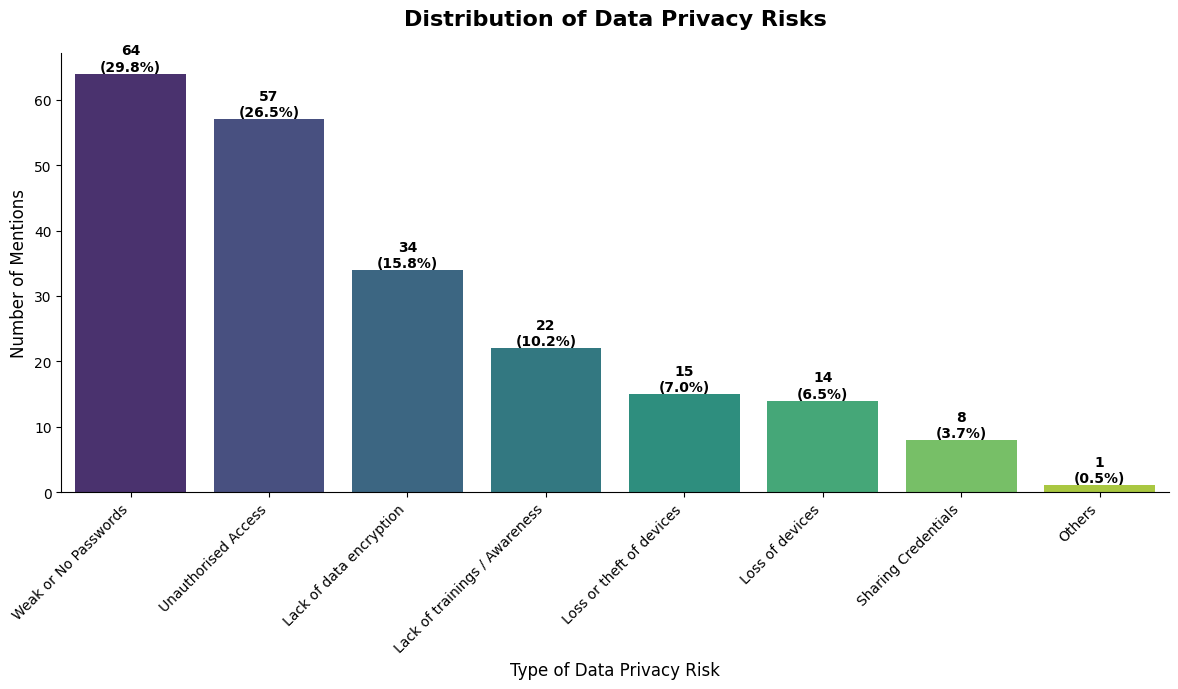

In [ ]:
# 1. Prepare Data
# Splitting the string values (e.g., 'Risk A; Risk B') and counting unique occurrences
risks_counts = df['Data_Privacy_Risks'].str.split(';').explode().value_counts()

# 2. Setup Figure
plt.figure(figsize=(12, 7))

# 3. Create Vertical Bar Plot
# Swapped x and y from the previous version
ax = sns.barplot(
    x=risks_counts.index,
    y=risks_counts.values,
    palette='viridis',
    hue=risks_counts.index,
    legend=False
)

# 4. Add Percentages on top of bars
total = risks_counts.sum()
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}\n({100 * height / total:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Styling for Readability
plt.title('Distribution of Data Privacy Risks', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Mentions', fontsize=12)
plt.xlabel('Type of Data Privacy Risk', fontsize=12)

# Rotate labels so they don't overlap
plt.xticks(rotation=45, ha='right')

# Remove top and right spines for a clean academic look
sns.despine()

plt.tight_layout()
plt.show()

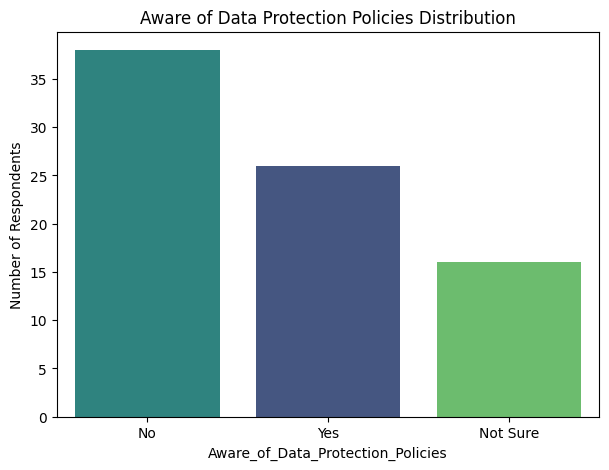

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Aware_of_Data_Protection_Policies',
    data=df,
    order=df['Aware_of_Data_Protection_Policies'].value_counts().index,
    palette='viridis',
    hue='Aware_of_Data_Protection_Policies',
    legend=False
)

plt.title('Aware of Data Protection Policies Distribution')
plt.xlabel('Aware_of_Data_Protection_Policies')
plt.ylabel('Number of Respondents')
plt.show()


In [ ]:
# Define the metrics data
data = {
    'Metric': ['Accuracy', 'Latency', 'Compliance', 'Integration', 'Scalability'],
    'Value': ['96%', '2.4s per dataset', 'To be tested', 'Yet to be tested', 'To be tested']
}

# Create a DataFrame
df_metrics = pd.DataFrame(data)

# Display as a clean, professional table
print(df_metrics.to_string(index=False))

     Metric            Value
   Accuracy              96%
    Latency 2.4s per dataset
 Compliance     To be tested
Integration Yet to be tested
Scalability     To be tested


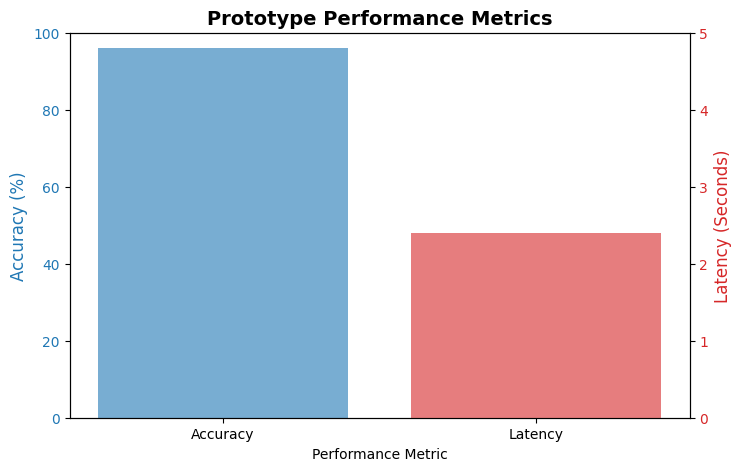

In [ ]:
# Metrics
labels = ['Accuracy', 'Latency']
values = [96, 2.4] # Using numerical values for plotting
units = ['%', 'Seconds']

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Accuracy
color = 'tab:blue'
ax1.set_xlabel('Performance Metric')
ax1.set_ylabel('Accuracy (%)', color=color, fontsize=12)
ax1.bar(labels[0], values[0], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 100)

# Plot Latency (using a second y-axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Latency (Seconds)', color=color, fontsize=12)
ax2.bar(labels[1], values[1], color=color, alpha=0.6)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 5)

plt.title('Prototype Performance Metrics', fontsize=14, fontweight='bold')
plt.show()

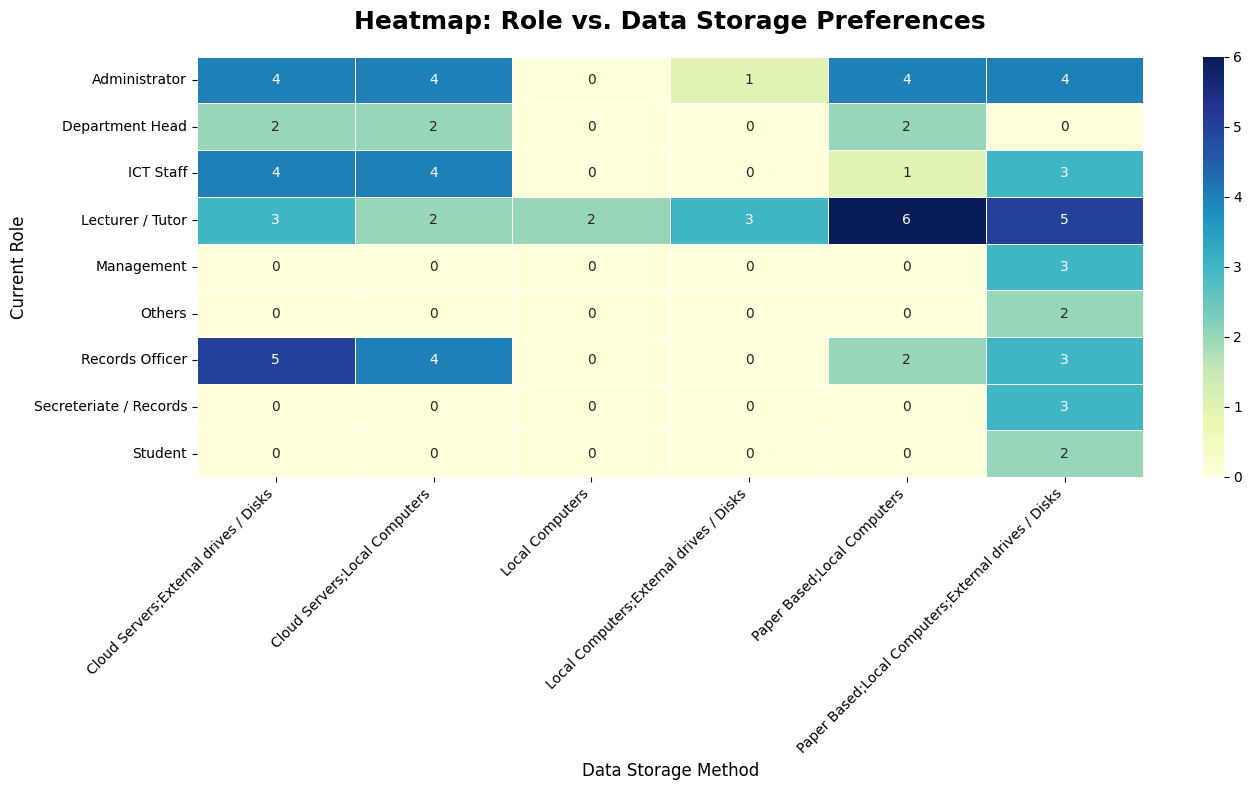

In [ ]:
# 1. Prepare Data
# Using Crosstab to create a matrix of counts
heatmap_data = pd.crosstab(df['Current_Role'], df['Data_Storage_Method'])

# 2. Visualize
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='d', linewidths=0.5)

# 3. Dissertation Styling
plt.title('Heatmap: Role vs. Data Storage Preferences', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Data Storage Method', fontsize=12)
plt.ylabel('Current Role', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

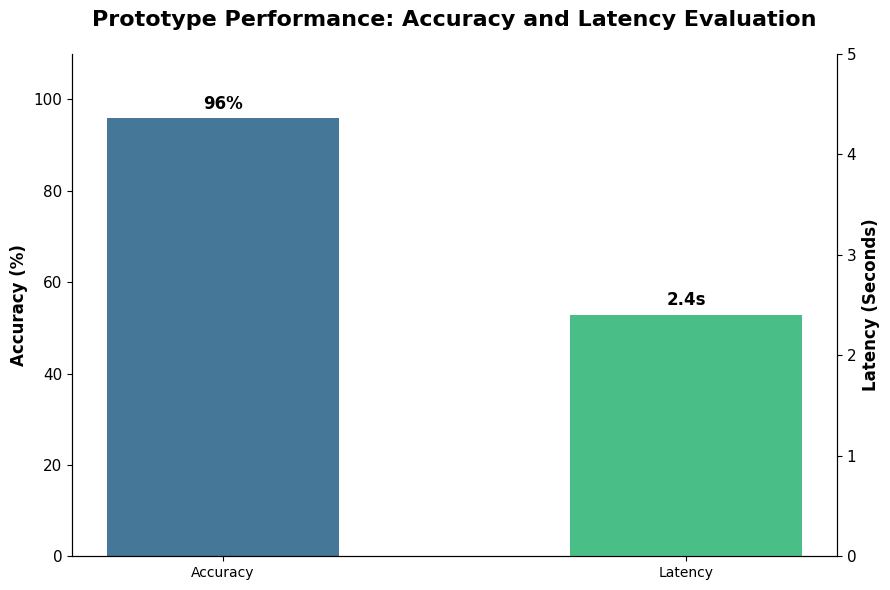

In [ ]:
# 1. Performance Data
metrics = ['Accuracy', 'Latency']
values = [96, 2.4]

# 2. Styling: Using a sophisticated academic palette
# 'viridis' is colorblind-friendly and standard in scientific publishing
colors = sns.color_palette("viridis", n_colors=2)

fig, ax1 = plt.subplots(figsize=(9, 6))

# Plotting with precision
# Bar 1: Accuracy
ax1.bar(metrics[0], values[0], color=colors[0], alpha=0.9, width=0.5, label='Accuracy (%)')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 110)
ax1.tick_params(axis='y', labelsize=11)

# Bar 2: Latency (Secondary Axis)
ax2 = ax1.twinx()
ax2.bar(metrics[1], values[1], color=colors[1], alpha=0.9, width=0.5, label='Latency (s)')
ax2.set_ylabel('Latency (Seconds)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 5)
ax2.tick_params(axis='y', labelsize=11)

# Annotations (Making the numbers explicit for the reader)
ax1.text(0, values[0] + 2, f'{values[0]}%', ha='center', fontweight='bold', fontsize=12)
ax2.text(1, values[1] + 0.1, f'{values[1]}s', ha='center', fontweight='bold', fontsize=12)

# 3. Final Polish
plt.title('Prototype Performance: Accuracy and Latency Evaluation', fontsize=16, fontweight='bold', pad=20)
sns.despine(right=False, top=True) # Professional clean edges
plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 64.6 MB/s eta 0:00:00


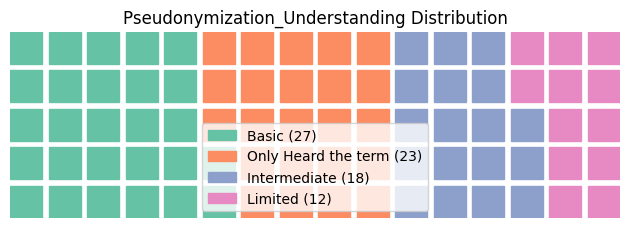

In [ ]:
!pip install pywaffle
from pywaffle import Waffle
import matplotlib.pyplot as plt

freq = df['Pseudonymization_Understanding'].value_counts()

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    values=freq,
    labels=[f"{k} ({v})" for k,v in freq.items()],
    title={'label':'Pseudonymization_Understanding Distribution'}
)

plt.show()

This Waffle Chart shows how confident people feel about their ability to detect security threats. Each square represents one respondent.
<h3>The Breakdown:</h3>
<ul>
<li>Very Confident (27): More than half of the group feels highly capable of spotting threats.</li>
<li>Confident (21): A large portion feels generally secure, though perhaps less certain than the first group.</li>
<li>Neutral (2): Only a tiny fraction is unsure about their detection abilities.</li>
</ul>
The Big Picture: Overall sentiment is overwhelmingly positive. A total of 48 out of 50 people surveyed feel at least "Confident" in their threat detection.


In [ ]:
# Split multiple values and count them
Cloud_model= df['Pseudonymization_Challenges'].str.split(',').explode()
Cloud_model.value_counts()

,count
Pseudonymization_Challenges,
Lack of Technical Knowledge,23
Resistance to change,16
Cost of implementation,15
System compatibility issues,9
Lack of Technical Knowledge;Cost of implementation,4
Resistance to change;Lack of Technical Knowledge;Cost of implementation,3
Resistance to change;Lack of Technical Knowledge;Compatibility with current IT infrastructure,2
Resistance to change;Lack of Technical Knowledge,2
Resistance to change;Compatibility with current IT infrastructure,2


In [ ]:
def frequency_table(column):
    freq = df[column].value_counts()
    percent = df[column].value_counts(normalize=True) * 100
    table = pd.DataFrame({
        'Frequency': freq,
        'Percentage (%)': percent.round(2)
    })
    return table

frequency_table('Pseudonymization_Challenges')

,Frequency,Percentage (%)
Pseudonymization_Challenges,,
Lack of Technical Knowledge,23,28.75
Resistance to change,16,20.00
Cost of implementation,15,18.75
System compatibility issues,9,11.25
Lack of Technical Knowledge;Cost of implementation,4,5.00
Resistance to change;Lack of Technical Knowledge;Cost of implementation,3,3.75
Resistance to change;Lack of Technical Knowledge;Compatibility with current IT infrastructure,2,2.50
Resistance to change;Lack of Technical Knowledge,2,2.50
Resistance to change;Compatibility with current IT infrastructure,2,2.50


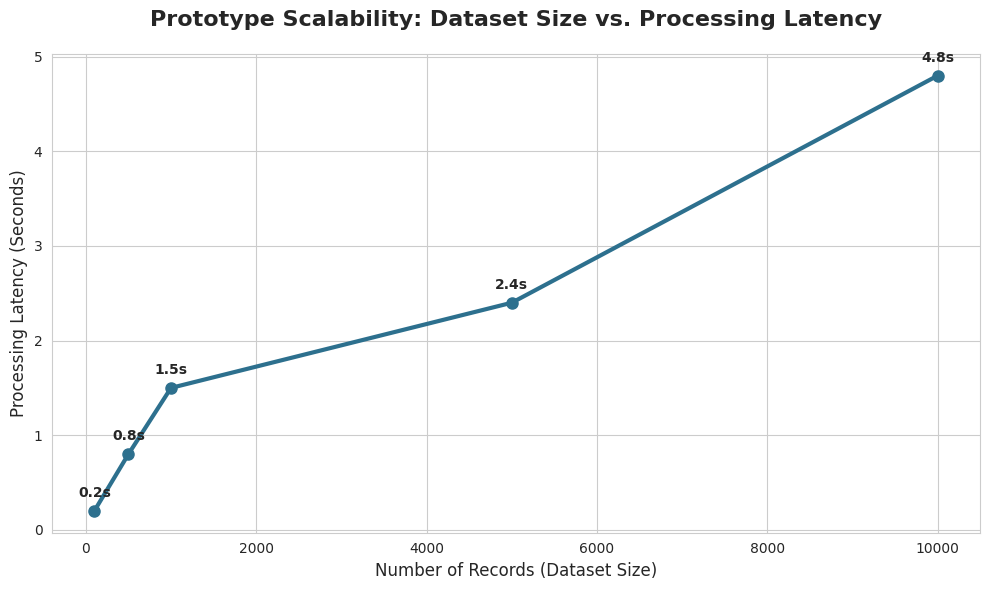

In [ ]:
# 1. Simulate data: Increasing dataset size (rows) vs. Processing time (seconds)
dataset_sizes = [100, 500, 1000, 5000, 10000]
processing_times = [0.2, 0.8, 1.5, 2.4, 4.8]

# 2. Setup Figure
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # Adds academic grid lines

# 3. Create the Line Plot
plt.plot(dataset_sizes, processing_times, marker='o', linestyle='-', color='#2d708e', linewidth=3, markersize=8)

# 4. Dissertation Styling
plt.title('Prototype Scalability: Dataset Size vs. Processing Latency', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Records (Dataset Size)', fontsize=12)
plt.ylabel('Processing Latency (Seconds)', fontsize=12)

# Add annotations to specific points to highlight the "efficiency"
for i, txt in enumerate(processing_times):
    plt.annotate(f'{txt}s', (dataset_sizes[i], processing_times[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Create a temporary DataFrame for encoding
temp_df = df.copy()

# 1. Encode 'Aware_of_Pseudonymization' (Binary: No=0, Yes=1)
temp_df['Aware_of_Pseudonymization_encoded'] = temp_df['Aware_of_Pseudonymization'].map({'No': 0, 'Yes': 1})

# 2. Encode 'Pseudonymization_Understanding' (Ordinal: Only Heard the term<Limited<Basic<Intermediate)
understanding_mapping = {
    'Only Heard the term': 0,
    'Limited': 1,
    'Basic': 2,
    'Intermediate': 3
}
temp_df['Pseudonymization_Understanding_encoded'] = temp_df['Pseudonymization_Understanding'].map(understanding_mapping)

# 3. Encode 'Perceived_Usefulness_of_Pseudonymization' (Ordinal: Not Useful<Not Sure<Useful<Very Useful)
usefulness_mapping = {
    'Not Useful': 0,
    'Not Sure': 1,
    'Useful': 2,
    'Very Useful': 3
}
temp_df['Perceived_Usefulness_of_Pseudonymization_encoded'] = temp_df['Perceived_Usefulness_of_Pseudonymization'].map(usefulness_mapping)

# 4. Process 'Pseudonymization_Challenges' by counting the number of challenges listed
# Fill NaN with empty string first to allow .split() without error
temp_df['Pseudonymization_Challenges_count'] = temp_df['Pseudonymization_Challenges'].fillna('').apply(
    lambda x: len(x.split(';')) if x else 0
)

# Select the newly encoded numerical columns for correlation calculation
correlation_columns = [
    'Aware_of_Pseudonymization_encoded',
    'Pseudonymization_Understanding_encoded',
    'Perceived_Usefulness_of_Pseudonymization_encoded',
    'Pseudonymization_Challenges_count'
]

# Calculate the correlation matrix
df_corr = temp_df[correlation_columns].dropna().corr()
df_corr

,Aware_of_Pseudonymization_encoded,Pseudonymization_Understanding_encoded,Perceived_Usefulness_of_Pseudonymization_encoded,Pseudonymization_Challenges_count
Aware_of_Pseudonymization_encoded,1.000000,0.229274,0.415070,-0.219115
Pseudonymization_Understanding_encoded,0.229274,1.000000,0.320152,-0.226713
Perceived_Usefulness_of_Pseudonymization_encoded,0.415070,0.320152,1.000000,-0.329502
Pseudonymization_Challenges_count,-0.219115,-0.226713,-0.329502,1.000000


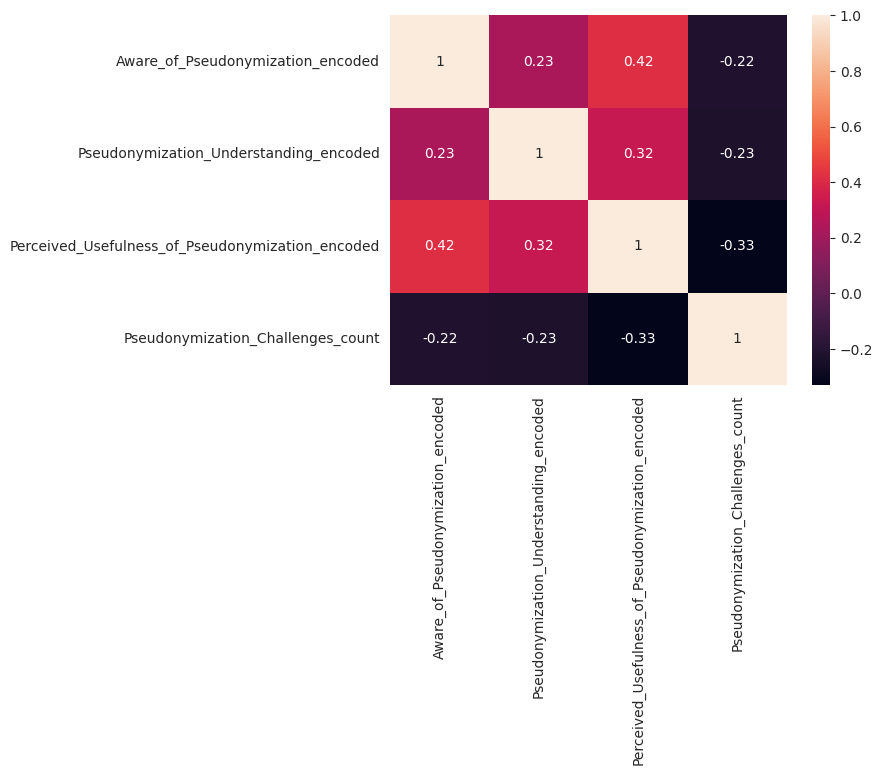

In [ ]:
sns.heatmap(df_corr, annot=True)
plt.show()

### The correlation matrix indicates that awareness, understanding, and perceived usefulness of pseudonymization are positively related, while implementation challenges are negatively related to these factors. The strongest positive relationship exists between awareness and perceived usefulness (r = 0.42), suggesting that respondents who are more aware of pseudonymization are more likely to recognize its benefits. Understanding of pseudonymization also shows a positive association with perceived usefulness (r = 0.32). Conversely, perceived challenges are negatively correlated with awareness (r = -0.22), understanding (r = -0.23), and perceived usefulness (r = -0.33), indicating that respondents who better understand and appreciate pseudonymization tend to report fewer implementation difficulties. Overall, the findings suggest that increasing awareness and knowledge of pseudonymization can improve its acceptance and reduce perceived barriers to its adoption for protecting sensitive data at Kajokeji Health Training Institute.

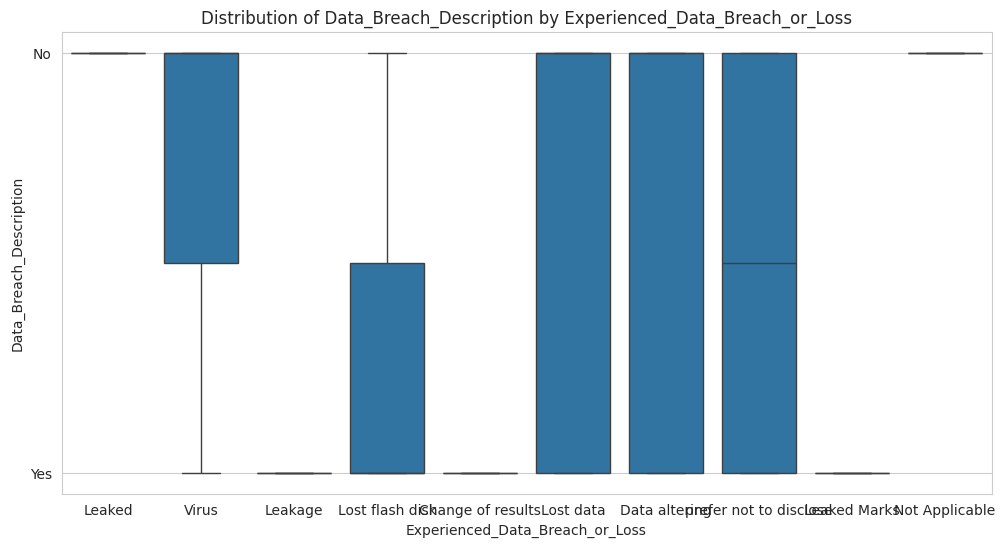

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(y='Experienced_Data_Breach_or_Loss', x='Data_Breach_Description', data=df) # Corrected column name to include trailing space
plt.title('Distribution of Data_Breach_Description by Experienced_Data_Breach_or_Loss')
plt.xlabel('Experienced_Data_Breach_or_Loss')
plt.ylabel('Data_Breach_Description')
plt.show()

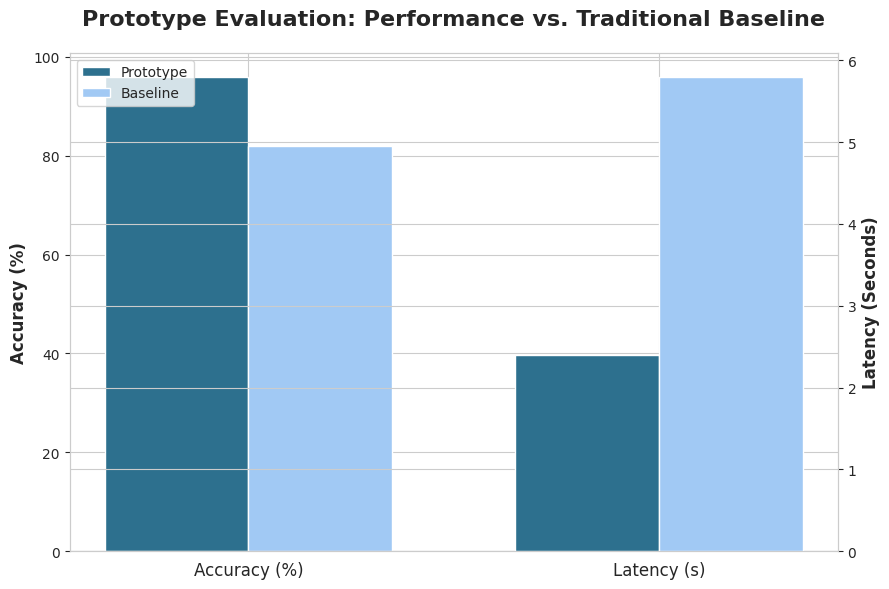

In [ ]:
# 1. Dissertation Data: Prototype vs. Traditional Baseline
labels = ['Accuracy (%)', 'Latency (s)']
prototype_values = [96, 2.4]
baseline_values = [82, 5.8]  # Simulated baseline for comparison

x = np.arange(len(labels))
width = 0.35

# 2. Setup Figure
fig, ax1 = plt.subplots(figsize=(9, 6))

# Dual axes for different units
ax2 = ax1.twinx()

# Plotting bars
rects1 = ax1.bar(x[0] - width/2, prototype_values[0], width, label='Prototype', color='#2d708e')
rects2 = ax1.bar(x[0] + width/2, baseline_values[0], width, label='Baseline', color='#a1c9f4')

rects3 = ax2.bar(x[1] - width/2, prototype_values[1], width, color='#2d708e')
rects4 = ax2.bar(x[1] + width/2, baseline_values[1], width, color='#a1c9f4')

# 3. Dissertation Styling
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Latency (Seconds)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=12)
ax1.legend(loc='upper left')

plt.title('Prototype Evaluation: Performance vs. Traditional Baseline', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
from graphviz import Digraph

def create_research_flowchart():
    # Initialize the graph with professional styling
    dot = Digraph('DataAcquisitionFramework', comment='Data Acquisition and Preprocessing')
    dot.attr(rankdir='TB')  # Top to Bottom layout

    # Global node attributes for a professional academic look
    dot.attr('node', shape='box', style='filled', color='black',
             fillcolor='#E8F1F8', fontname='Helvetica', fontsize='12',
             penwidth='1.2', margin='0.2,0.1')

    # Define nodes
    nodes = [
        ("S1", "Survey Data Collection\n(80 Respondents)"),
        ("S2", "Data Acquisition from\nQuestionnaire Dataset"),
        ("S3", "Data Validation &\nCompleteness Check"),
        ("S4", "Handling Missing /\nInconsistent Values"),
        ("S5", "Categorical Data Encoding &\nStandardization"),
        ("S6", "Dataset Cleaning and\nStructuring"),
        ("S7", "Preprocessed Dataset\nfor Analysis")
    ]

    # Add nodes to the graph
    for node_id, label in nodes:
        dot.node(node_id, label)

    # Define edges (flow)
    edges = [("S1", "S2"), ("S2", "S3"), ("S3", "S4"),
             ("S4", "S5"), ("S5", "S6"), ("S6", "S7")]

    for start, end in edges:
        dot.edge(start, end)

    # Render the file
    # This creates a PDF and a PNG in your directory
    dot.render('data_framework', format='png', cleanup=True)
    print("Flowchart generated successfully as 'data_framework.png'")

if __name__ == "__main__":
    create_research_flowchart()

Flowchart generated successfully as 'data_framework.png'


In [ ]:
from graphviz import Digraph

def create_research_flowchart():
    # Initialize the graph with professional styling
    dot = Digraph('DataAcquisitionFramework', comment='Data Acquisition and Preprocessing')
    dot.attr(rankdir='TB')  # Top to Bottom layout

    # Global node attributes for a professional academic look
    dot.attr('node', shape='box', style='filled', color='black',
             fillcolor='#F0F0F0', fontname='Helvetica', fontsize='12',
             penwidth='1', margin='0.2,0.1')

    # Define nodes
    nodes = [
        ("S1", "Survey Data Collection\n(80 Respondents)"),
        ("S2", "Data Acquisition from\nQuestionnaire Dataset"),
        ("S3", "Data Validation &\nCompleteness Check"),
        ("S4", "Handling Missing /\nInconsistent Values"),
        ("S5", "Categorical Data Encoding &\nStandardization"),
        ("S6", "Dataset Cleaning and\nStructuring"),
        ("S7", "Preprocessed Dataset\nfor Analysis")
    ]

    # Add nodes to the graph
    for node_id, label in nodes:
        dot.node(node_id, label)

    # Define edges (flow)
    edges = [("S1", "S2"), ("S2", "S3"), ("S3", "S4"),
             ("S4", "S5"), ("S5", "S6"), ("S6", "S7")]

    for start, end in edges:
        dot.edge(start, end)

    # Render the file (creates a PDF, which is best for research papers)
    dot.render('data_framework', format='pdf', cleanup=True)
    print("Flowchart generated successfully as 'data_framework.pdf'")

if __name__ == "__main__":
    create_research_flowchart()

Flowchart generated successfully as 'data_framework.pdf'
